# Wireless Coverage — Part 3b: Raster-Pixel Surfaces (the pixel counterpoint)

![Wireless Coverage Part 3b — raster-pixel contrast: 1 m DSM vs H3 cells, raster and H3 viewshed](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/wireless-coverage/wireless-coverage-03b.png)

Part 3a took the LiDAR surfaces **beyond pixels** into an H3 discrete global grid. This
notebook is the honest counterpoint: it holds the native **1 m raster** representation up
next to that H3 grid, and then re-runs Part 4's tower-siting question on the **raster** side
so you can see the two paradigms score the *same* ground.

- **Part A — representation contrast.** The same Golden Gate Park window as a 1 m-pixel DSM
  raster *and* as nb3a's H3 cells. Real counts: millions of pixels vs a few hundred cells at
  res 10 — and the resolution is a *dial*, not a ceiling (a res-15 cell is sub-metre, finer
  than a 1 m pixel). Where each representation wins.
- **Part B — viewshed foil.** A spread of candidate towers across the Golden Gate Park LiDAR
  footprint, each scored with the **raster** per-tower viewshed (`rst_viewshed_towers`); the
  strongest become the demo towers and are compared to the **H3-cell** viewshed — both computed
  here — on a common metric (coverage area within the 2.5 km disk). Raster is pixel-exact per
  tower; H3 scales to a cheap screening pass that rules most sites out first.

> **Runtime.** Databricks Serverless environment 6 — the [lightweight tier](https://databrickslabs.github.io/geobrix/docs/api/execution-tiers) (pure Python/PySpark + `h3`, no JAR). `DEMO=True` runs the Golden Gate Park sub-AOI; at full scale the per-tower raster viewshed is a one-tower-per-task (Lakeflow) fan-out.

---
**Last Update:** 2026-10-05

In [0]:
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet "geobrix[light_env6,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

In [0]:
%run ./config_nb

AOI EPSG:3857: x=[-13642204, -13619940] y=[4537132, 4558257]
Tile: 1024 m = 1024 px | H3_RESOLUTION = 10


In [0]:
# ── nb3b overrides (after %run ./config_nb) ─────────────────────────────────
# config_nb provides: F, DBF, rx, _tbl, _persist, _points_as_gdf, cells_as_gdf,
#   plot_static, plot_raster, raster_layer, vector_layer, lonlat_to_3857,
#   X0, Y0, TILE_M, TPX, PIXEL_M, CATALOG, SCHEMA, OUT_DIR.
import os, re, math, time
import h3
import geopandas as _gpd
import pyproj
from shapely.geometry import box as _box, Point as _Pt

from databricks.labs.gbx.pyrx import rst_viewshed_towers       # Task 2 — per-tower raster viewshed
from databricks.labs.gbx.pygx import h3_los_visible            # promoted H3 line-of-sight (nb4's model)
from databricks.labs.gbx.ds._listing import list_files, to_local_path

DEMO            = True
FORCE_RELOAD    = False
OUT_PREFIX      = "wc_rpx"           # raster-pixel outputs: wc_rpx_*

# Siting constants mirror nb4 so Part B compares like-for-like (both viewsheds computed HERE —
# nb3b is self-contained: it reads only nb2's DSM, Part 3a, and config_nb, all of which precede it).
RADIUS_M        = 2500.0             # 5G urban coverage buffer (nb4 MAX_DIST_M)
ANTENNA_ABOVE_SURFACE_M = 10.0       # observer this far above the DSM (nb4 antenna clearance)
TARGET_H        = 1.6                # receiver height above the surface at the target
VIEWSHED_RES        = 12                 # viewshed resolution (nb4 VIEWSHED_RES); its H3 viewshed_cells
RES_FINE_BIN    = 13                 # finest H3 surface bin before roll-up to VIEWSHED_RES (nb4 SURFACE_BIN_RES)
TOWER_RES       = 9                  # candidate lattice: one tower per res-9 cell centroid (nb4)
N_CANDIDATES    = 24                 # spread of candidates the raster viewshed scans (one tower/task)
N_DEMO_TOWERS   = 5                  # strongest N candidates (by visible_px) kept as demo towers

GGP_LON, GGP_LAT = -122.486, 37.769  # Golden Gate Park center (series demo anchor)
WIN_TILES_A     = 2                  # Part A representation window: 2x2 tiles around GGP

VRT_DIR         = f"{OUT_DIR}/_nb3b_rvs_vrt"   # durable per-tower VRTs (Volume)
_to4326         = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

# res-cell areas (equal-area on the sphere) — the resolution dial, in m^2.
A10 = h3.average_hexagon_area(10, unit="m^2")
A12 = h3.average_hexagon_area(VIEWSHED_RES, unit="m^2")
A15 = h3.average_hexagon_area(15, unit="m^2")
print(f"DEMO={DEMO} | radius={RADIUS_M:.0f}m | antenna +{ANTENNA_ABOVE_SURFACE_M:.0f}m above DSM")
print(f"H3 cell area (m^2): res 10 ~ {A10:,.0f} | res 12 ~ {A12:,.1f} | res 15 ~ {A15:,.2f}")

DEMO=True | radius=2500m | antenna +10m above DSM
H3 cell area (m^2): res 10 ~ 15,048 | res 12 ~ 307.1 | res 15 ~ 0.90


## Part A — the same ground, two representations

A raster is a **regular grid of square pixels**; an H3 grid is a **discrete global grid
system (DGGS)** of hexagonal cells. Over one 2x2-tile (~2 km) window around Golden Gate Park
we count how many *pixels* vs how many *cells* it takes to tile the same ground.

> **Resolution is a dial, not a ceiling.** The raster is fixed at 1 m. H3 rolls to *any*
> resolution via `h3_toparent` + a GROUP BY: a res-10 cell is ~15,000 m^2, res 12 ~307 m^2,
> and a **res-15 cell is ~0.9 m^2 — finer than a 1 m pixel** (nb1 already stored `cellid_r15`
> on every point). "Beyond pixels" is the DGGS paradigm — hierarchical, equal-area, globally
> addressable cells — not a coarser grid.

In [0]:
# Window = 2x2 tiles around the Golden Gate Park center tile.
_gx, _gy = lonlat_to_3857(GGP_LON, GGP_LAT)
_tx0 = int((_gx - X0) // TILE_M)
_ty0 = int((_gy - Y0) // TILE_M)
_tx1, _ty1 = _tx0 + WIN_TILES_A, _ty0 + WIN_TILES_A

dsm_r = spark.table(_tbl("wc_surface", "dsm"))          # 1 m DSM STRUCT tiles (EPSG:3857)
_win = F.col("tx").between(_tx0, _tx1 - 1) & F.col("ty").between(_ty0, _ty1 - 1)
n_tiles = dsm_r.where(_win).count()
n_px = n_tiles * int(TPX) * int(TPX)                    # 1 m^2 per pixel

# Window box in lon/lat (EPSG:4326) + projected bounds (EPSG:3857) for H3 + framing.
_wx0, _wy0 = X0 + _tx0 * TILE_M, Y0 + _ty0 * TILE_M
_wx1, _wy1 = X0 + _tx1 * TILE_M, Y0 + _ty1 * TILE_M
_w, _s = _to4326.transform(_wx0, _wy0)
_e, _n = _to4326.transform(_wx1, _wy1)
_win_wkb = _box(_w, _s, _e, _n).wkb
_win_area = (WIN_TILES_A * TILE_M) ** 2                 # projected window area (m^2)


def _h3_tiling_count(res):
    """How many H3 cells cover the window box at this resolution."""
    return (spark.createDataFrame([(1,)], "g int")
            .select(F.explode(DBF.h3_try_coverash3(F.lit(_win_wkb), F.lit(res))).alias("c"))
            .where(F.col("c").isNotNull()).count())


n_h3_10 = _h3_tiling_count(10)
n_h3_12 = _h3_tiling_count(VIEWSHED_RES)
n_h3_15_est = int(_win_area / A15)                      # res 15 is ~millions — estimate, don't materialize

dsm_h3 = spark.table(_tbl("wc_h3", "dsm", 10))          # nb3a's gridded DSM surface (res 10)
n_dsm_cells_r10 = dsm_h3.select("cellid").distinct().count()

print(f"Window: {n_tiles} tile(s) tx[{_tx0}..{_tx1 - 1}] ty[{_ty0}..{_ty1 - 1}] "
      f"= {WIN_TILES_A * int(TILE_M)} m per side")
print(f"  raster 1 m pixels            : {n_px:,}")
print(f"  H3 cells @res 10 (~{A10:,.0f} m^2) : {n_h3_10:,}")
print(f"  H3 cells @res 12 (~{A12:,.0f} m^2)   : {n_h3_12:,}")
print(f"  H3 cells @res 15 (~{A15:.2f} m^2)      : ~{n_h3_15_est:,}  (sub-metre, finer than a 1 m pixel)")
print(f"nb3a stored DSM surface (res 10, demo): {n_dsm_cells_r10:,} distinct cells")

Window: 4 tile(s) tx[6..7] ty[9..10] = 2048 m per side
  raster 1 m pixels            : 4,194,304
  H3 cells @res 10 (~15,048 m^2) : 199
  H3 cells @res 12 (~307 m^2)   : 8,418
  H3 cells @res 15 (~0.90 m^2)      : ~4,684,742  (sub-metre, finer than a 1 m pixel)
nb3a stored DSM surface (res 10, demo): 1,087 distinct cells


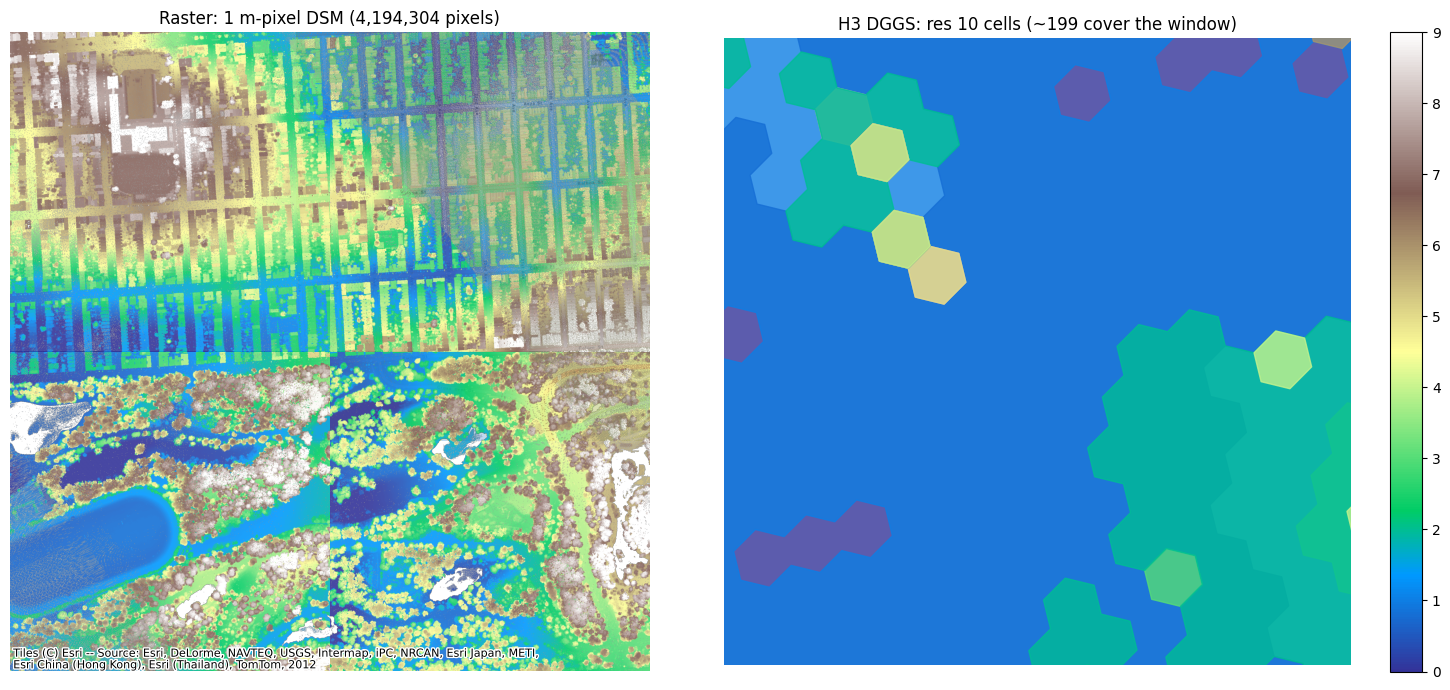

In [0]:
# Side-by-side: the 1 m DSM raster window vs the nb3a H3-gridded DSM surface (res 10).
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: 1 m-pixel DSM raster mosaic over the window.
_ras = []
for _tx in range(_tx0, _tx1):
    for _ty in range(_ty0, _ty1):
        _row = dsm_r.where((F.col("tx") == _tx) & (F.col("ty") == _ty)).first()
        if _row is not None:
            _ras.append(raster_layer(_row["dsm"], band=1, cmap="terrain", opacity=0.9,
                                     label="DSM 1 m pixel (m)" if not _ras else None))
if _ras:
    plot_static(_ras, title=f"Raster: 1 m-pixel DSM ({n_px:,} pixels)", ax=axes[0])
    axes[0].set_xlim(_wx0, _wx1)
    axes[0].set_ylim(_wy0, _wy1)

# Right: nb3a's H3-gridded DSM surface (res 10), dissolved by elevation band, same window.
_dsm_gdf = cells_as_gdf(dsm_h3, "cellid", extra_cols=["band_level"],
                        dissolve_by="band_level", dissolve_engine="product")
_dsm_win = _dsm_gdf.to_crs(3857).cx[_wx0:_wx1, _wy0:_wy1]
plot_static(_dsm_win, column="band_level", cmap="terrain", basemap=False, ax=axes[1],
            title=f"H3 DGGS: res 10 cells (~{n_h3_10:,} cover the window)")
axes[1].set_xlim(_wx0, _wx1)
axes[1].set_ylim(_wy0, _wy1)
plt.tight_layout()

**The trade-off.**

- **Raster (regular square grid).** Dense and exact at its fixed resolution — millions of 1 m
  pixels here. But every source lives in its *own* grid and CRS, so joining DSM to CHM to a
  different sensor means **resample / warp** to a common grid first, and the pixel count
  explodes with area. (Even "1 m" is slippery: these pixels are 1 m in EPSG:3857, which is
  Mercator-inflated at this latitude — real ground pitch is sub-metre.)
- **H3 (DGGS hexagons).** A few hundred cells cover the same window at res 10. Cells are
  **globally addressable** (the same id anywhere on Earth), **equal-area**, and **hierarchical**
  — `h3_toparent` rolls any surface up or down a resolution with a GROUP BY, so DEM/DSM/CHM and
  the tower analysis all share one id space and join directly (no warp). And it is not a
  resolution ceiling: dial to res 15 and a cell is finer than the 1 m pixel.

## Part B — viewshed foil: raster pixels vs H3 cells, same towers

Part 4 (later in the series) sites towers with an H3-cell line-of-sight; here we run **both**
viewsheds ourselves on the **same** towers so the comparison stands alone — nb3b reads only nb2's
DSM, Part 3a, and `config_nb`, never a Part-4 table. We:

1. **Pick the towers** by regenerating Part 4's res-9 centroid lattice over the DSM-covered footprint,
   scoring a spatially-spread pool of candidates with the raster viewshed, and keeping the strongest few
   by visible coverage (so the demo towers are genuinely high-visibility sites, not just the lattice centre).
2. **Raster viewshed** (`rst_viewshed_towers`, Task 2): per tower, select the in-radius DSM tiles,
   mint one bytes-free VRT, run a single pixel-level GDAL/xrspatial viewshed, histogram the coverage.
3. **H3 viewshed** (`h3_los_visible`, promoted to the library): bin the DSM to a res-12 surface
   in-notebook and run the same line-of-sight over H3 cells — Part 4's exact model.

Both use the identical siting assumptions: observer +10 m above the DSM, target +1.6 m, radius 2.5 km.

In [0]:
# DSM COG manifest (path, tx, ty): list the COG dir and parse dsm_<tx>_<ty>.tif basenames.
# The DSM STRUCT table has NULL .path, so path windowing MUST read the COG dir, not the table.
# The regex matches the basename (not a path-anchored dsm_... form). _tiles is the covered set.
DSM_DIR = f"{OUT_DIR}/dsm"
_tile_re = re.compile(r"dsm_(-?\d+)_(-?\d+)\.tif$")
_rows = []
for _p in list_files(DSM_DIR, filter_regex=r".*\.tif$", recursive=False):
    _m = _tile_re.search(os.path.basename(_p))
    if _m:
        _rows.append((to_local_path(_p), int(_m.group(1)), int(_m.group(2))))
assert _rows, f"no DSM COGs under {DSM_DIR}"
dsm_tiles_df = spark.createDataFrame(_rows, "path string, tx int, ty int")
_tiles = {(r[1], r[2]) for r in _rows}                  # covered (tx, ty) set
print(f"DSM COGs: {len(_rows)} tile(s) "
      f"tx[{min(r[1] for r in _rows)}..{max(r[1] for r in _rows)}] "
      f"ty[{min(r[2] for r in _rows)}..{max(r[2] for r in _rows)}]")

DSM COGs: 25 tile(s) tx[4..8] ty[7..11]


In [0]:
# Candidate towers: regenerate Part 4's res-9 centroid lattice INDEPENDENTLY (no Part-4 table) over
# the FULL DSM COG footprint, not just the GGP centre. Keep cells whose 1 m DSM near-window (observer
# tile + all 8 neighbours) is fully present, then take a spatially-SPREAD pool so candidates reach the
# GGP edges / clearings / higher ground. The raster viewshed (next cell) scores every candidate and the
# strongest N by visible coverage become the demo towers — so the demo is high-visibility, not centroid.
def _well_covered(x, y):
    """True when the observer tile and all 8 neighbours are present in the DSM COG dir."""
    tx = int((x - X0) // TILE_M)
    ty = int((y - Y0) // TILE_M)
    return all((tx + dx, ty + dy) in _tiles for dx in (-1, 0, 1) for dy in (-1, 0, 1))


# res-9 lattice over the COG footprint bounding box (derived from the covered-tile set _tiles).
_fx0 = X0 + min(tx for tx, ty in _tiles) * TILE_M
_fy0 = Y0 + min(ty for tx, ty in _tiles) * TILE_M
_fx1 = X0 + (max(tx for tx, ty in _tiles) + 1) * TILE_M
_fy1 = Y0 + (max(ty for tx, ty in _tiles) + 1) * TILE_M
_fw, _fs = _to4326.transform(_fx0, _fy0)
_fe, _fn = _to4326.transform(_fx1, _fy1)
_lattice_wkb = _box(_fw, _fs, _fe, _fn).wkb
_lattice = [r["c"] for r in spark.createDataFrame([(1,)], "g int")
            .select(F.explode(DBF.h3_try_coverash3(F.lit(_lattice_wkb), F.lit(TOWER_RES))).alias("c"))
            .where(F.col("c").isNotNull()).collect()]

_cand_all = []
for _c in _lattice:
    _la, _lo = h3.cell_to_latlng(h3.int_to_str(_c))
    _x, _y = lonlat_to_3857(_lo, _la)
    if _well_covered(_x, _y):
        _cand_all.append((int(_c), float(_x), float(_y)))
assert _cand_all, "no res-9 lattice cell has a fully-covered DSM near-window"

# Deterministic spatial spread: bin the covered extent into a ~sqrt(N) grid and keep the cell nearest
# each bin centre, so the pool spans the footprint instead of clustering in one spot.
_xs = [c[1] for c in _cand_all]
_ys = [c[2] for c in _cand_all]
_minx, _maxx, _miny, _maxy = min(_xs), max(_xs), min(_ys), max(_ys)
_spanx, _spany = max(_maxx - _minx, 1.0), max(_maxy - _miny, 1.0)
_nb = max(1, round(N_CANDIDATES ** 0.5))
_bins = {}
for _cell, _x, _y in _cand_all:
    _i = min(_nb - 1, int((_x - _minx) / _spanx * _nb))
    _j = min(_nb - 1, int((_y - _miny) / _spany * _nb))
    _bcx = _minx + (_i + 0.5) * _spanx / _nb
    _bcy = _miny + (_j + 0.5) * _spany / _nb
    _d = (_x - _bcx) ** 2 + (_y - _bcy) ** 2
    if (_i, _j) not in _bins or _d < _bins[(_i, _j)][0]:
        _bins[(_i, _j)] = (_d, (_cell, _x, _y))
_cands = sorted((v[1] for v in _bins.values()), key=lambda t: t[0])   # deterministic by cell id
candidates_df = spark.createDataFrame(
    [(c, x, y) for c, x, y in _cands], "tower_cellid long, x double, y double")
print(f"candidate towers: {len(_cands)} spread of {len(_cand_all)} well-covered res-{TOWER_RES} "
      f"cells across the COG footprint (raster viewshed keeps the top {N_DEMO_TOWERS})")

candidate towers: 25 spread of 54 well-covered res-9 cells across the COG footprint (raster viewshed keeps the top 5)


In [0]:
# Raster viewshed over EVERY candidate, then keep the strongest N by visible pixels as the demo
# towers. One bytes-free VRT window per tower, one pixel-level viewshed, histogrammed to in-radius
# coverage (reprojected to 4326). num_partitions defaults to the candidate count — one tower per
# task, the natural Lakeflow fan-out at full San-Francisco scale.
os.makedirs(VRT_DIR, exist_ok=True)
_rvs_tbl = _tbl(OUT_PREFIX, "raster_viewshed")
if FORCE_RELOAD or not spark.catalog.tableExists(_rvs_tbl):
    _cand_rvs = rst_viewshed_towers(
        candidates_df, dsm_tiles_df,
        radius_m=RADIUS_M, observer_height=ANTENNA_ABOVE_SURFACE_M,
        x0=X0, y0=Y0, tile_m=TILE_M,
        target_height=TARGET_H, to_crs=4326, vrt_dir=VRT_DIR,
        tower_id_col="tower_cellid", x_col="x", y_col="y",
    )
    # Rank candidates by visible coverage; the strongest N become the demo towers.
    _top = (_cand_rvs.where(F.col("visible_px") > 0)
            .orderBy(F.col("visible_px").desc()).limit(N_DEMO_TOWERS))
    rvs = _persist(_top, "raster_viewshed")             # -> wc_rpx_raster_viewshed_demo (top N)
else:
    rvs = spark.table(_rvs_tbl)
# Demo towers = the persisted top-N; recover lon/lat from the stored observer coords (EPSG:3857).
demo = []
for _r in (rvs.orderBy(F.col("visible_px").desc())
           .select("tower_cellid", "observer_x", "observer_y").collect()):
    _lo, _la = _to4326.transform(float(_r["observer_x"]), float(_r["observer_y"]))
    demo.append({"cellid": int(_r["tower_cellid"]), "lon": float(_lo), "lat": float(_la)})
assert demo, "no candidate tower returned visible_px > 0 — widen the candidate pool or the COG dir"
print(f"raster viewshed -> {_rvs_tbl} (strongest {len(demo)} of the candidate scan by visible_px)")
rvs.orderBy(F.col("visible_px").desc()).show(truncate=False)
_vagg = rvs.agg(F.min("visible_px").alias("lo"), F.max("visible_px").alias("hi")).first()
print(f"visible_px across demo towers: {_vagg['lo']:,} .. {_vagg['hi']:,} (strongest first)")

raster viewshed -> geospatial_docs.geobrix.wc_rpx_raster_viewshed_demo (strongest 5 of the candidate scan by visible_px)
+------------------+---------------------+------------------+----------+--------+-----------------+---------------+--------------------+
|tower_cellid      |observer_x           |observer_y        |visible_px|total_px|visible_px_reproj|total_px_reproj|frac                |
+------------------+---------------------+------------------+----------+--------+-----------------+---------------+--------------------+
|617700175062237183|-1.3634879654640172E7|4545641.1645669   |1299038   |20971520|1203538          |19424710       |0.06194295883178711 |
|617700175121481727|-1.363498553404306E7 |4547884.917982331 |1149863   |20971520|1064543          |19419168       |0.054829740524291994|
|617700175065645055|-1.3634900827976115E7|4546089.9000832215|1112262   |26214400|1081917          |25503200       |0.04242942810058594 |
|617700175058567167|-1.3635657580009142E7|4545565.4065581

In [0]:
# Inline H3 viewshed (Part 4's model, self-contained): bin the DSM to a res-13 H3 surface over
# the demo window, roll up to res-12 (max height per cell), and run h3_los_visible per tower —
# observer = DSM + 10 m, target + 1.6 m, 2.5 km (surface-relative: ground_z = surface_z). Persisted
# so a re-run skips the bin. Reads nb2's DSM only — no Part-4 table.
_h3vs_tbl = _tbl(OUT_PREFIX, "h3_viewshed")
_h3cov_tbl = _tbl(OUT_PREFIX, "h3_coverage")
if FORCE_RELOAD or not (spark.catalog.tableExists(_h3vs_tbl) and spark.catalog.tableExists(_h3cov_tbl)):
    _t0 = time.time()
    (spark.table(_tbl("wc_surface", "dsm"))             # nb2 DSM STRUCT tiles (EPSG:3857)
     .select("tx", "ty", rx.rst_transform("dsm", F.lit(4326)).alias("t4326"))
     .repartition(64, "tx", "ty").createOrReplaceTempView("_nb3b_dsm_bin"))
    # res-13 max-height H3 bin, then roll up to res-12 (max of children) — nb4's exact pattern.
    _surf13 = spark.sql(
        f"SELECT t.cellID AS cell, max(t.measure) AS z FROM _nb3b_dsm_bin, "
        f"LATERAL gbx_rst_h3_rastertogridmax(t4326, {RES_FINE_BIN}) t WHERE t.band = 1 GROUP BY t.cellID")
    _surf12 = (_surf13.groupBy(DBF.h3_toparent("cell", F.lit(VIEWSHED_RES)).alias("cell"))
               .agg(F.max("z").alias("z")))
    surf_map = {h3.int_to_str(r["cell"]): r["z"] for r in _surf12.collect()}
    cxy = {}
    for _c in surf_map:
        _la, _lo = h3.cell_to_latlng(_c)
        cxy[_c] = lonlat_to_3857(_lo, _la)
    print(f"H3 surface bin ({time.time() - _t0:.0f}s): {len(surf_map):,} res-{VIEWSHED_RES} cells over the window")
    _h3rows, _h3cov = [], {}
    for d in demo:
        tcell = h3.latlng_to_cell(d["lat"], d["lon"], VIEWSHED_RES)
        st = surf_map.get(tcell)
        if st is None:
            _h3rows.append((int(d["cellid"]), 0))
            continue
        tw = lonlat_to_3857(d["lon"], d["lat"])
        tgts = [c for c, (x, y) in cxy.items()
                if (x - tw[0]) ** 2 + (y - tw[1]) ** 2 <= RADIUS_M * RADIUS_M]
        vis = h3_los_visible(tcell, st + ANTENNA_ABOVE_SURFACE_M, tgts, surf_map, surf_map, TARGET_H)
        _h3rows.append((int(d["cellid"]), int(len(vis))))
        for vc in vis:
            _h3cov[vc] = _h3cov.get(vc, 0) + 1
    h3_vs = _persist(spark.createDataFrame(_h3rows, "tower_cellid long, h3_viewshed_cells long"),
                     "h3_viewshed")
    h3_cov_df = _persist(with_join_parent(spark.createDataFrame(
        [(h3.str_to_int(c), int(n)) for c, n in _h3cov.items()],
        "cellid long, tower_los_count long")), "h3_coverage")
else:
    h3_vs = spark.table(_h3vs_tbl)
    h3_cov_df = spark.table(_h3cov_tbl)
print(f"inline H3 viewshed -> {_h3vs_tbl}")
h3_vs.orderBy(F.col("h3_viewshed_cells").desc()).show(truncate=False)

inline H3 viewshed -> geospatial_docs.geobrix.wc_rpx_h3_viewshed_demo
+------------------+-----------------+
|tower_cellid      |h3_viewshed_cells|
+------------------+-----------------+
|617700175121481727|7467             |
|617700175062237183|6575             |
|617700175061188607|6187             |
|617700175065645055|6040             |
|617700175058567167|5279             |
+------------------+-----------------+



In [0]:
# Comparable metric: coverage AREA within the 2.5 km disk. Raster = visible_px x 1 m^2
# (EPSG:3857 projected); H3 = viewshed_cells x res-12 cell area (equal-area on the sphere).
# These are not identical measurement systems: the raster area is projected m^2 (Mercator-inflated
# ~1/cos^2(lat) at this latitude) while H3 cells are true spherical area, so the disk-normalised %
# is a close comparison, not an exact one — and that projection mismatch is itself the "regular
# grid needs resample/warp to join" cost. Both viewsheds were computed above: same towers, same model.
_latlon = spark.createDataFrame(
    [(int(d["cellid"]), float(d["lon"]), float(d["lat"])) for d in demo],
    "tower_cellid long, lon double, lat double")
_DISK = math.pi * RADIUS_M * RADIUS_M
compare = (rvs.join(h3_vs, "tower_cellid").join(_latlon, "tower_cellid")
           .withColumn("raster_area_m2", F.col("visible_px") * F.lit(PIXEL_M * PIXEL_M))
           .withColumn("h3_area_m2", F.col("h3_viewshed_cells") * F.lit(A12))
           .withColumn("raster_pct_disk", F.round(100.0 * F.col("raster_area_m2") / F.lit(_DISK), 1))
           .withColumn("h3_pct_disk", F.round(100.0 * F.col("h3_area_m2") / F.lit(_DISK), 1))
           .select("tower_cellid", "lon", "lat", "visible_px", "raster_area_m2", "raster_pct_disk",
                   "h3_viewshed_cells", "h3_area_m2", "h3_pct_disk")
           .orderBy(F.col("visible_px").desc()))
compare = _persist(compare, "comparison")               # -> wc_rpx_comparison_demo
print(f"raster-vs-H3 coverage -> {_tbl(OUT_PREFIX, 'comparison')}")
compare.show(truncate=False)

raster-vs-H3 coverage -> geospatial_docs.geobrix.wc_rpx_comparison_demo
+------------------+-------------------+-----------------+----------+--------------+---------------+-----------------+------------------+-----------+
|tower_cellid      |lon                |lat              |visible_px|raster_area_m2|raster_pct_disk|h3_viewshed_cells|h3_area_m2        |h3_pct_disk|
+------------------+-------------------+-----------------+----------+--------------+---------------+-----------------+------------------+-----------+
|617700175062237183|-122.48420790893567|37.76045483576216|1299038   |1299038.0     |6.6            |6575             |2019129.0822778095|10.3       |
|617700175121481727|-122.48515903979457|37.77638799052146|1149863   |1149863.0     |5.9            |7467             |2293055.035341202 |11.7       |
|617700175065645055|-122.48439811224861|37.76364163363906|1112262   |1112262.0     |5.7            |6040             |1854834.9288149003|9.4        |
|617700175058567167|-122.491

**The trade-off — and why the two coverage columns diverge.**

- **Raster viewshed — pixel-exact, per tower.** Every 1 m cell in the DSM window is tested, so
  the coverage footprint is as precise as the input. The cost is per-tower work over a dense
  grid; the pipeline keeps it Serverless-safe by minting one window VRT per tower (no raster
  bytes cross a shuffle) and fanning out **one tower per task** — the natural unit for a
  Lakeflow run at full San-Francisco scale.
- **H3 viewshed — scalable screening.** Binning the surface to one **max height per ~17 m
  res-12 cell** turns line-of-sight into a cheap cell count — the model Part 4 scales to the
  whole lattice with a coarse quick-pass that **rules most candidate sites out** before any
  detailed work, and which joins straight to demand, land-cover, and other H3 layers.

**Read the gap, not just the numbers.** The H3 coverage above runs higher than the raster coverage
for the same tower (and the gap widens the rougher the surface is). That is the expected signature of
surface binning, **not a defect**: collapsing the 1 m surface to one max-height value per ~17 m
cell smooths out the fine terrain and structure blockers that a 1 m raster line-of-sight respects —
so a cell counts as "seen" wherever its single binned height is visible, inflating coverage. The
H3 figure is therefore an **optimistic screening estimate**; the raster figure is the **strict,
pixel-level confirmation**. Same towers, same 2.5 km disk, same +10 m antenna: screen the lattice
cheaply with H3, then confirm a shortlisted site's exact footprint with the raster viewshed.

## Maps — a raster-pixel viewshed beside the H3-cell coverage

The strongest demo tower's **raster** viewshed (visible vs not, at 1 m) next to the **inline
H3-cell** coverage depth (how many demo towers see each res-12 cell) — both computed above in this
notebook. Two paradigms, one scene.

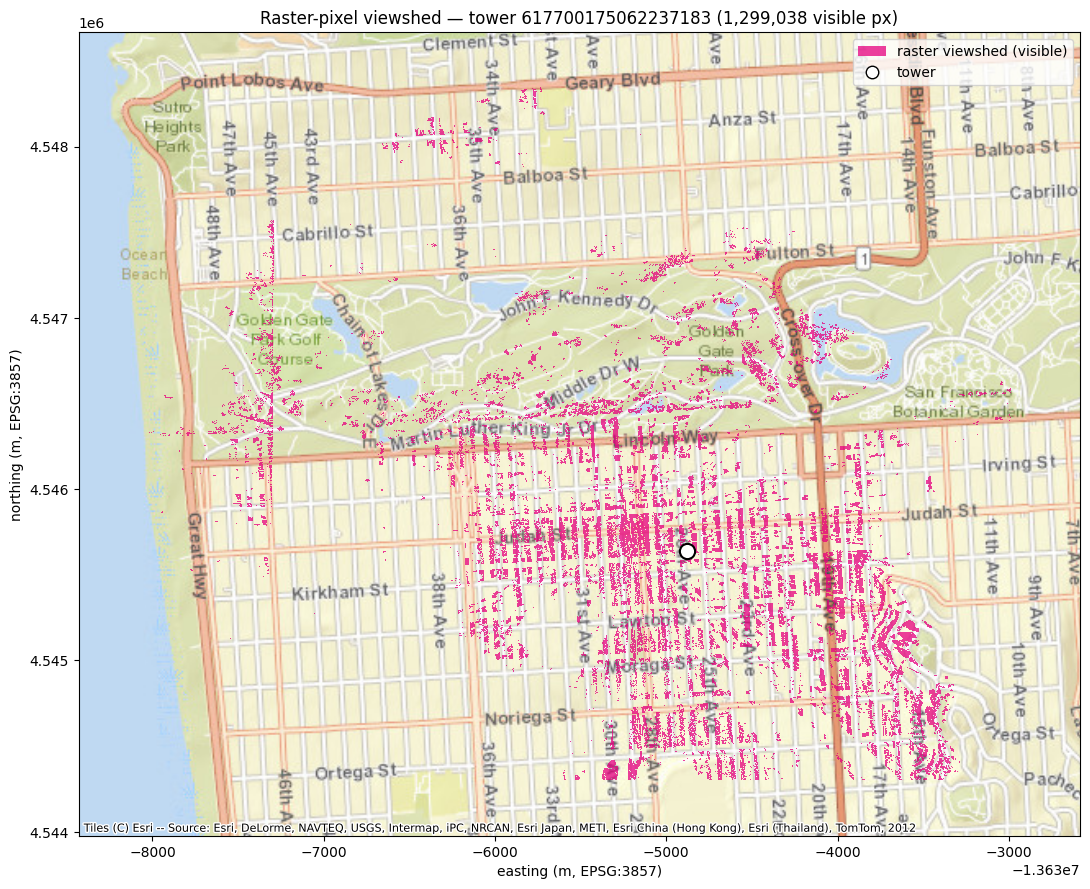

In [0]:
# Raster-pixel viewshed map — the strongest demo tower's exact pixel viewshed over the series Esri
# basemap, in NATIVE EPSG:3857 (so it aligns with the tower). Only the VISIBLE footprint draws:
# invisible pixels are fully transparent and the visible pixels are ONE saturated colour that pops
# over the light street tiles. (The viewshed carries no NoData and plot_static applies a single
# scalar alpha to an in-memory raster — both would leave the invisible 0-pixels showing — so the
# footprint is overlaid here as a masked array; the Esri basemap is the same provider plot_static
# uses.) Zoomed to the visible-pixel extent in 3857 metres.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from rasterio.io import MemoryFile
from rasterio.plot import plotting_extent
from rasterio.transform import xy as _rxy

_top = compare.orderBy(F.col("visible_px").desc()).first()
_tcell = int(_top["tower_cellid"])
_lon, _lat = float(_top["lon"]), float(_top["lat"])
_tx_m, _ty_m = lonlat_to_3857(_lon, _lat)
_vrt = f"{VRT_DIR}/tower_{_tcell}.vrt"
if os.path.exists(_vrt):
    _obs = f"POINT ({_tx_m:.6f} {_ty_m:.6f})"
    _vs = (spark.createDataFrame([(_vrt,)], "vrt string")
           .withColumn("dem", rx.rst_fromfile("vrt", materialize=False))
           .withColumn("vs", rx.rst_viewshed("dem", F.lit(_obs), ANTENNA_ABOVE_SURFACE_M,
                                             TARGET_H, RADIUS_M, materialize=True))
           .select("vs").first()["vs"])
    with MemoryFile(bytes(_vs["raster"])) as _mf, _mf.open() as _src:
        _arr = _src.read(1)
        _tr = _src.transform
    _vis = _arr >= 128                                   # viewshed visible class (255)
    _VIS_COLOR = "#E6007E"                               # vivid magenta — pops over light street tiles
    fig, ax = plt.subplots(figsize=(11, 10))
    # Visible footprint in one vivid colour at 0.75 opacity; invisible pixels masked -> transparent.
    _step = max(1, max(_arr.shape) // 2000)
    _vd = _vis[::_step, ::_step]
    _layer = np.ma.masked_where(~_vd, np.ones(_vd.shape, dtype="uint8"))
    ax.imshow(_layer, extent=plotting_extent(_arr, _tr), cmap=ListedColormap([_VIS_COLOR]),
              vmin=0, vmax=1, alpha=0.75, zorder=3, interpolation="nearest")
    ax.scatter([_tx_m], [_ty_m], c="white", edgecolors="black", s=120, linewidths=1.5, zorder=5)
    # Zoom to the visible-pixel extent (3857 metres — the axes CRS).
    _ys, _xs = np.where(_vis)
    if _xs.size:
        _xa, _ya = _rxy(_tr, int(_ys.min()), int(_xs.min()))
        _xb, _yb = _rxy(_tr, int(_ys.max()), int(_xs.max()))
        _xlo, _xhi = min(_xa, _xb), max(_xa, _xb)
        _ylo, _yhi = min(_ya, _yb), max(_ya, _yb)
        _px = max((_xhi - _xlo) * 0.08, 1.0)
        _py = max((_yhi - _ylo) * 0.08, 1.0)
        ax.set_xlim(_xlo - _px, _xhi + _px)
        ax.set_ylim(_ylo - _py, _yhi + _py)
    # Series Esri basemap (same provider plot_static uses), fetched for the zoomed EPSG:3857 extent.
    try:
        import contextily as cx
        from databricks.labs.gbx.vizx._basemap import _basemap_add_kwargs, _resolve_basemap_source
        cx.add_basemap(ax, crs="EPSG:3857", source=_resolve_basemap_source(None),
                       **_basemap_add_kwargs())
    except Exception as _e:
        print(f"basemap unavailable ({type(_e).__name__}: {_e}); rendering without it")
    ax.set_title(f"Raster-pixel viewshed — tower {_tcell} ({int(_top['visible_px']):,} visible px)")
    ax.set_xlabel("easting (m, EPSG:3857)")
    ax.set_ylabel("northing (m, EPSG:3857)")
    ax.legend(handles=[
        Patch(facecolor=_VIS_COLOR, alpha=0.75, edgecolor="none", label="raster viewshed (visible)"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
               markeredgecolor="black", markersize=9, label="tower"),
    ], loc="upper right")
    plt.tight_layout()
else:
    print(f"VRT {_vrt} not found — raster viewshed map skipped")

<Axes: title={'center': 'H3-cell viewshed depth (res 12) — inline h3_los_visible over the demo towers'}, xlabel='Easting [metre]', ylabel='Northing [metre]'>

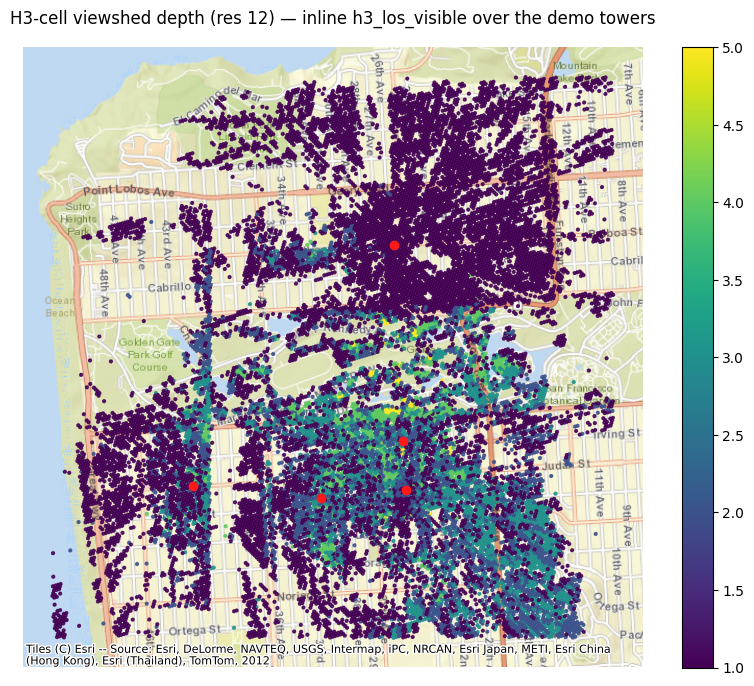

In [0]:
# H3-cell viewshed map — the inline per-cell coverage depth (how many demo towers see each
# res-12 cell), from the h3_los_visible pass above, with the demo towers overlaid. No Part-4 table.
_cov_gdf = cells_as_gdf(h3_cov_df, "cellid", extra_cols=("tower_los_count",), max_rows=200_000)
_twrs = _gpd.GeoDataFrame(
    geometry=[_Pt(float(d["lon"]), float(d["lat"])) for d in demo], crs="EPSG:4326")
plot_static([
    vector_layer(_cov_gdf, geom_col="geometry", column="tower_los_count", cmap="viridis",
                 opacity=0.85, label=f"demo towers with LOS (res {VIEWSHED_RES})"),
    vector_layer(_twrs, geom_col="geometry", color="#FF1A1A", opacity=1.0, label="demo tower"),
], title=f"H3-cell viewshed depth (res {VIEWSHED_RES}) — inline h3_los_visible over the demo towers")

## Summary

Side by side, the raster and the H3 grid describe the *same* Golden Gate Park surface and the
*same* tower viewsheds — but they are not rivals at a fixed resolution. The raster is a dense,
exact, single-CRS grid; H3 is a hierarchical, equal-area, globally-addressable grid that dials
to any resolution (res 15 is finer than a 1 m pixel) and joins directly across surfaces,
demand, and land cover.

**Beyond pixels is DGGS superpowers at any resolution — not a resolution ceiling.** Reach for
the raster viewshed when you need a shortlisted tower's exact footprint; reach for H3 to screen
the whole lattice cheaply and to compose coverage into the rest of the analysis.

Both viewsheds are computed here, so nb3b stands alone — it depends only on nb2's DSM, Part 3a, and
`config_nb`, all earlier in the series. Outputs: `wc_rpx_raster_viewshed` (per-tower raster
coverage), `wc_rpx_h3_viewshed` / `wc_rpx_h3_coverage` (the inline H3 viewshed + per-cell depth),
and `wc_rpx_comparison` (raster vs H3 coverage area on the shared 2.5 km-disk metric).